In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

In [2]:
# Constants and config
REPO_ROOT = Path("../")
DATA_PATH = REPO_ROOT / "data" / "simulated_users.csv"

# For evaluation, collapse three-tier label to binary:
# high_confidence_abuse -> 1, suspected -> 1, clean -> 0
# This is a deliberate simplification for precision/recall reporting only.
# The underlying data retains the three-tier label.
ABUSE_TIERS = {"high_confidence_abuse": 1, "suspected": 1, "clean": 0}

PLOT_STYLE = "seaborn-v0_8-whitegrid"
FIGSIZE = (12, 5)
COLOR_ABUSE = "#e74c3c"
COLOR_CLEAN = "#2ecc71"
COLOR_SUSPECTED = "#f39c12"

# Rule-Based Abuse Detection

This notebook defines and evaluates 8 heuristic detection rules against the simulated dataset.

Rules are evaluated individually (precision, recall, F1) and in combination (AND / OR logic).
The goal is not to build the best classifier — it's to understand which signals carry real discriminative power and what the tradeoffs look like before introducing a learned model.

**Setup:** Run `python 04_data/simulate_abuse_accounts.py` first to generate the data.

## 1. Load Data

In [3]:
df = pd.read_csv(DATA_PATH)

# Binary ground truth for evaluation (not used as training labels)
df["is_abuse_binary"] = df["abuse_confidence"].map(ABUSE_TIERS)

print(f"Dataset: {len(df):,} accounts")
print(f"\nAbuse confidence distribution:")
print(df["abuse_confidence"].value_counts().to_string())
print(f"\nOverall abuse rate (suspected + high confidence): {df['is_abuse_binary'].mean():.1%}")

Dataset: 5,000 accounts

Abuse confidence distribution:
abuse_confidence
clean                    3925
high_confidence_abuse     556
suspected                 519

Overall abuse rate (suspected + high confidence): 21.5%


## 2. Signal Distribution Visualization

Before defining rules, compare signal distributions across abuse tiers to confirm discriminative value.

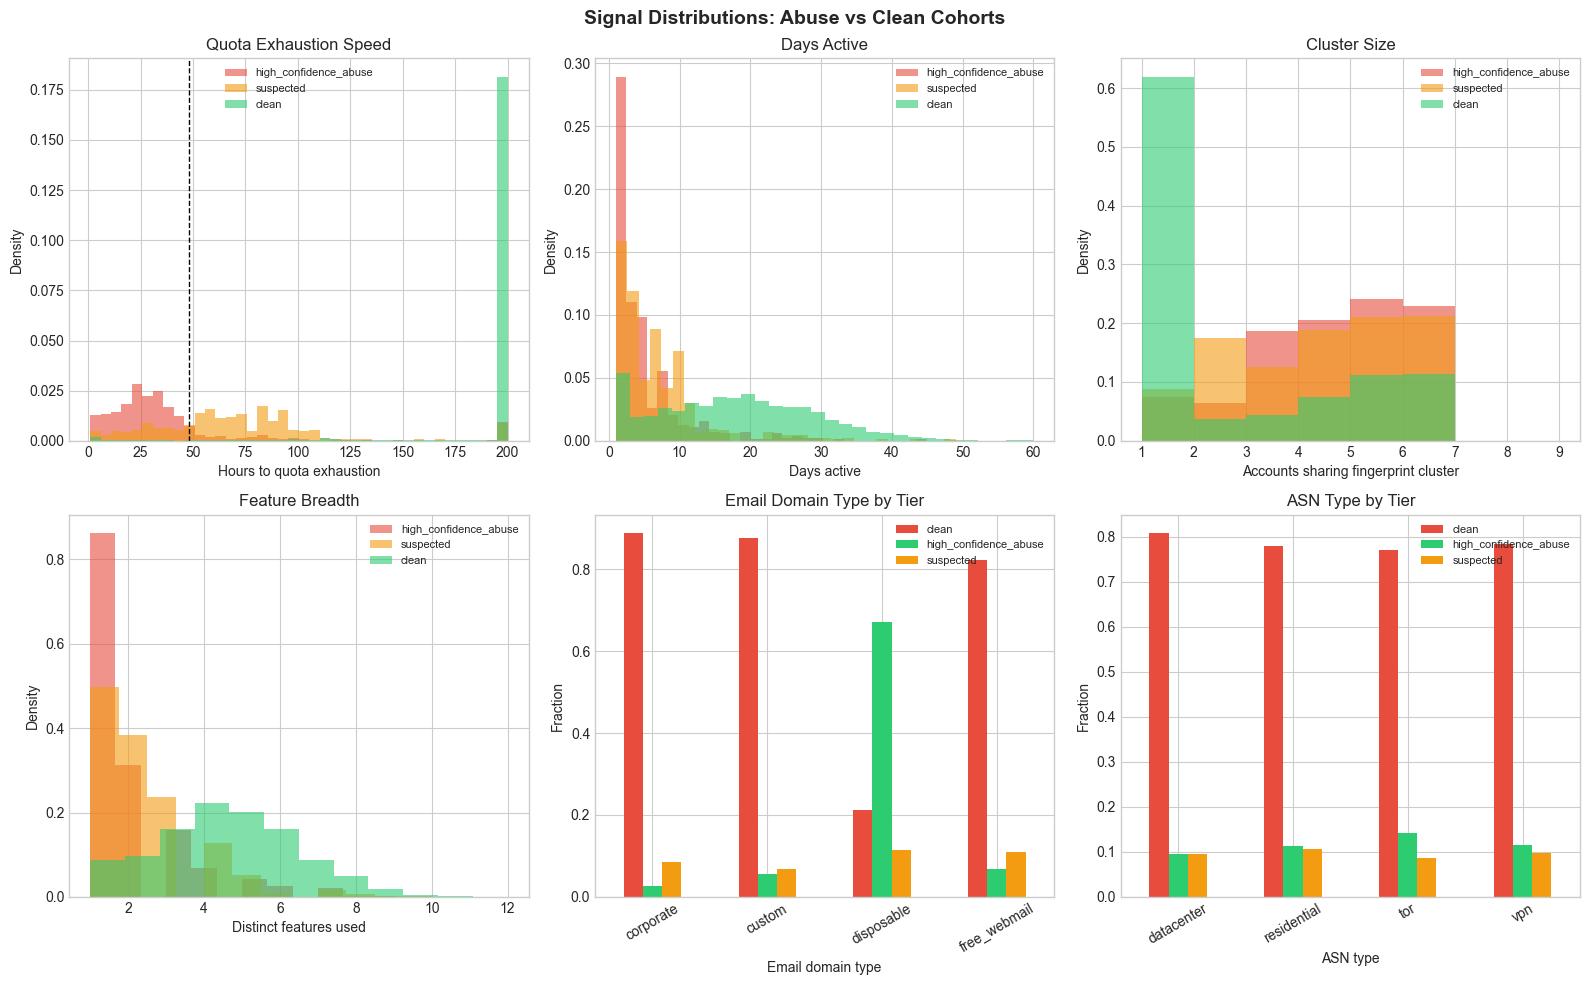

Figure: Signal distributions across abuse confidence tiers. Abuse accounts show faster quota exhaustion, smaller cluster sizes are less discriminative due to legitimate IP sharing, and disposable email domains are strongly concentrated in the high-confidence tier.


In [4]:
plt.style.use(PLOT_STYLE)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Signal Distributions: Abuse vs Clean Cohorts", fontsize=14, fontweight="bold")

color_map = {
    "high_confidence_abuse": COLOR_ABUSE,
    "suspected": COLOR_SUSPECTED,
    "clean": COLOR_CLEAN,
}

# Plot 1: Hours to quota exhaustion
ax = axes[0, 0]
for tier, color in color_map.items():
    subset = df[df["abuse_confidence"] == tier]["hours_to_quota_exhaustion"].dropna()
    ax.hist(subset.clip(0, 200), bins=40, alpha=0.6, color=color, label=tier, density=True)
ax.set_xlabel("Hours to quota exhaustion")
ax.set_ylabel("Density")
ax.set_title("Quota Exhaustion Speed")
ax.legend(fontsize=8)
ax.axvline(48, color="black", linestyle="--", linewidth=1, label="48h threshold")

# Plot 2: Days active
ax = axes[0, 1]
for tier, color in color_map.items():
    subset = df[df["abuse_confidence"] == tier]["days_active"]
    ax.hist(subset.clip(0, 60), bins=30, alpha=0.6, color=color, label=tier, density=True)
ax.set_xlabel("Days active")
ax.set_ylabel("Density")
ax.set_title("Days Active")
ax.legend(fontsize=8)

# Plot 3: Accounts in cluster
ax = axes[0, 2]
for tier, color in color_map.items():
    subset = df[df["abuse_confidence"] == tier]["accounts_in_cluster"]
    ax.hist(subset, bins=range(1, 10), alpha=0.6, color=color, label=tier, density=True)
ax.set_xlabel("Accounts sharing fingerprint cluster")
ax.set_ylabel("Density")
ax.set_title("Cluster Size")
ax.legend(fontsize=8)

# Plot 4: Features used
ax = axes[1, 0]
for tier, color in color_map.items():
    subset = df[df["abuse_confidence"] == tier]["features_used"]
    ax.hist(subset.clip(0, 12), bins=12, alpha=0.6, color=color, label=tier, density=True)
ax.set_xlabel("Distinct features used")
ax.set_ylabel("Density")
ax.set_title("Feature Breadth")
ax.legend(fontsize=8)

# Plot 5: Email domain type
ax = axes[1, 1]
domain_abuse = df.groupby(["email_domain_type", "abuse_confidence"]).size().unstack(fill_value=0)
domain_abuse_pct = domain_abuse.div(domain_abuse.sum(axis=1), axis=0)
domain_abuse_pct.plot(kind="bar", ax=ax, color=[COLOR_ABUSE, COLOR_CLEAN, COLOR_SUSPECTED])
ax.set_xlabel("Email domain type")
ax.set_ylabel("Fraction")
ax.set_title("Email Domain Type by Tier")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=8)

# Plot 6: ASN type
ax = axes[1, 2]
asn_abuse = df.groupby(["asn_type", "abuse_confidence"]).size().unstack(fill_value=0)
asn_abuse_pct = asn_abuse.div(asn_abuse.sum(axis=1), axis=0)
asn_abuse_pct.plot(kind="bar", ax=ax, color=[COLOR_ABUSE, COLOR_CLEAN, COLOR_SUSPECTED])
ax.set_xlabel("ASN type")
ax.set_ylabel("Fraction")
ax.set_title("ASN Type by Tier")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print("Figure: Signal distributions across abuse confidence tiers. Abuse accounts show faster quota exhaustion, smaller cluster sizes are less discriminative due to legitimate IP sharing, and disposable email domains are strongly concentrated in the high-confidence tier.")

## 3. Rule Definitions

Eight heuristic rules, each returning a boolean Series indicating which accounts are flagged.

In [5]:
def rule_disposable_email(df: pd.DataFrame) -> pd.Series:
    """Flag accounts using known disposable email domains."""
    return df["email_domain_type"] == "disposable"


def rule_fast_quota_exhaust(df: pd.DataFrame, threshold_hours: float = 48.0) -> pd.Series:
    """Flag accounts that exhausted their quota within threshold_hours."""
    return (df["quota_exhausted"] == True) & (
        df["hours_to_quota_exhaustion"] <= threshold_hours
    )


def rule_ip_cluster(df: pd.DataFrame, min_cluster_size: int = 3) -> pd.Series:
    """Flag accounts in a fingerprint cluster with >= min_cluster_size accounts."""
    return df["accounts_in_cluster"] >= min_cluster_size


def rule_no_return_after_exhaust(df: pd.DataFrame) -> pd.Series:
    """Flag accounts that exhausted quota and never returned."""
    return (df["quota_exhausted"] == True) & (df["return_after_exhaustion"] == False)


def rule_vpn_datacenter_asn(df: pd.DataFrame) -> pd.Series:
    """Flag accounts accessing from datacenter or VPN ASNs."""
    return df["asn_type"].isin(["datacenter", "vpn", "tor"])


def rule_low_session_depth(df: pd.DataFrame, max_avg_duration: float = 5.0) -> pd.Series:
    """Flag accounts with very short average session duration (probe-and-leave pattern)."""
    return df["avg_session_duration_mins"] <= max_avg_duration


def rule_narrow_feature_use(df: pd.DataFrame, max_features: int = 2) -> pd.Series:
    """Flag accounts that used very few distinct product features."""
    return df["features_used"] <= max_features


def rule_high_api_low_days(df: pd.DataFrame, api_threshold: int = 500, day_threshold: int = 5) -> pd.Series:
    """Flag accounts with high API usage concentrated in very few active days."""
    return (df["api_calls_count"] >= api_threshold) & (df["days_active"] <= day_threshold)


RULES = {
    "R1: Disposable email": rule_disposable_email,
    "R2: Fast quota exhaust (<48h)": rule_fast_quota_exhaust,
    "R3: IP cluster (>=3 accounts)": rule_ip_cluster,
    "R4: No return after exhaust": rule_no_return_after_exhaust,
    "R5: Datacenter/VPN ASN": rule_vpn_datacenter_asn,
    "R6: Low session depth (<5 min)": rule_low_session_depth,
    "R7: Narrow feature use (<=2)": rule_narrow_feature_use,
    "R8: High API, low days": rule_high_api_low_days,
}

print(f"Defined {len(RULES)} rules.")

Defined 8 rules.


## 4. Per-Rule Evaluation

In [6]:
y_true = df["is_abuse_binary"].values

results = []
for rule_name, rule_fn in RULES.items():
    y_pred = rule_fn(df).astype(int).values
    n_flagged = y_pred.sum()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    results.append({
        "Rule": rule_name,
        "Flagged": n_flagged,
        "Flag rate": f"{n_flagged / len(df):.1%}",
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1": round(f1, 3),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                          Rule  Flagged Flag rate  Precision  Recall    F1
          R1: Disposable email      424      8.5%      0.788   0.311 0.446
 R2: Fast quota exhaust (<48h)      513     10.3%      0.949   0.453 0.613
 R3: IP cluster (>=3 accounts)     2212     44.2%      0.389   0.801 0.524
   R4: No return after exhaust     1217     24.3%      0.549   0.621 0.583
        R5: Datacenter/VPN ASN     1242     24.8%      0.203   0.234 0.218
R6: Low session depth (<5 min)      403      8.1%      0.558   0.209 0.304
  R7: Narrow feature use (<=2)     1443     28.9%      0.540   0.725 0.619
        R8: High API, low days      711     14.2%      0.762   0.504 0.607


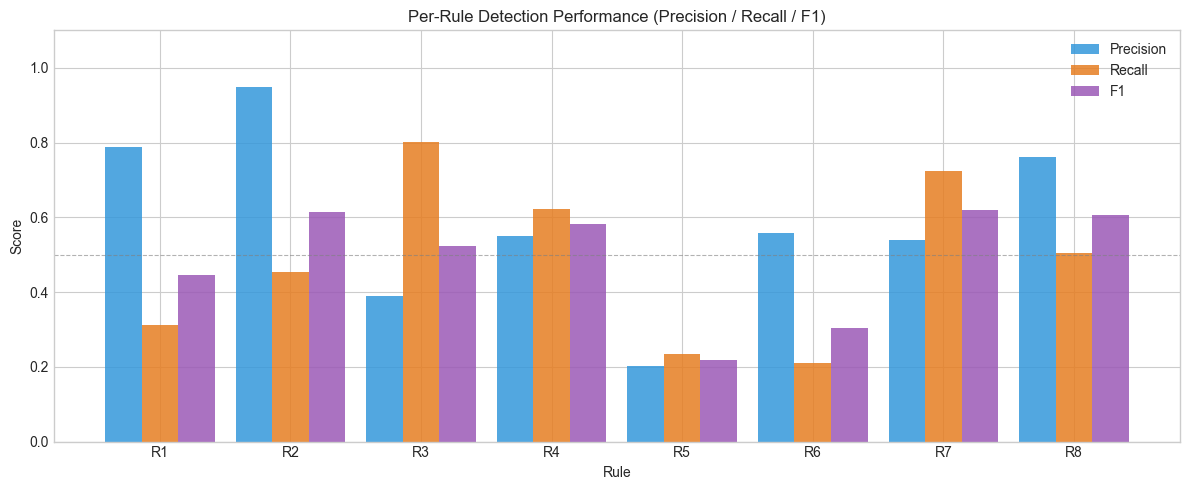

Figure: Precision, recall, and F1 for each individual rule. High-precision rules (disposable email, fast exhaust) have low recall — they catch only a subset of abuse. High-recall rules (IP cluster, no return) flag too many legitimate accounts.


In [7]:
fig, ax = plt.subplots(figsize=FIGSIZE)

x = np.arange(len(results_df))
width = 0.28

bars1 = ax.bar(x - width, results_df["Precision"], width, label="Precision", color="#3498db", alpha=0.85)
bars2 = ax.bar(x, results_df["Recall"], width, label="Recall", color="#e67e22", alpha=0.85)
bars3 = ax.bar(x + width, results_df["F1"], width, label="F1", color="#9b59b6", alpha=0.85)

ax.set_xlabel("Rule")
ax.set_ylabel("Score")
ax.set_title("Per-Rule Detection Performance (Precision / Recall / F1)")
ax.set_xticks(x)
ax.set_xticklabels([r.split(":")[0] for r in results_df["Rule"]], rotation=0)
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.show()
print("Figure: Precision, recall, and F1 for each individual rule. High-precision rules (disposable email, fast exhaust) have low recall — they catch only a subset of abuse. High-recall rules (IP cluster, no return) flag too many legitimate accounts.")

## 5. Rule Combination Logic

No single rule is sufficient. We evaluate OR (any rule fires), AND (all rules fire), and a weighted signal count threshold.

In [8]:
# Compute signal flags for each rule
rule_flags = pd.DataFrame({
    name: fn(df).astype(int) for name, fn in RULES.items()
})

# OR combination: flag if ANY rule fires
y_or = (rule_flags.sum(axis=1) >= 1).astype(int)

# AND combination: flag if ALL rules fire (very strict)
y_and = (rule_flags.sum(axis=1) == len(RULES)).astype(int)

# Signal count threshold: flag if N or more rules fire
combination_results = []
for threshold in range(1, len(RULES) + 1):
    y_thresh = (rule_flags.sum(axis=1) >= threshold).astype(int)
    precision = precision_score(y_true, y_thresh, zero_division=0)
    recall = recall_score(y_true, y_thresh, zero_division=0)
    f1 = f1_score(y_true, y_thresh, zero_division=0)
    combination_results.append({
        "Min rules fired": threshold,
        "Flagged": int(y_thresh.sum()),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1": round(f1, 3),
    })

combo_df = pd.DataFrame(combination_results)
print("Signal Count Threshold Results:")
print(combo_df.to_string(index=False))

Signal Count Threshold Results:
 Min rules fired  Flagged  Precision  Recall    F1
               1     3728      0.275   0.954 0.427
               2     2010      0.474   0.886 0.617
               3     1031      0.789   0.756 0.772
               4      630      0.959   0.562 0.709
               5      423      0.979   0.385 0.553
               6      246      0.992   0.227 0.369
               7       85      0.976   0.077 0.143
               8       12      1.000   0.011 0.022


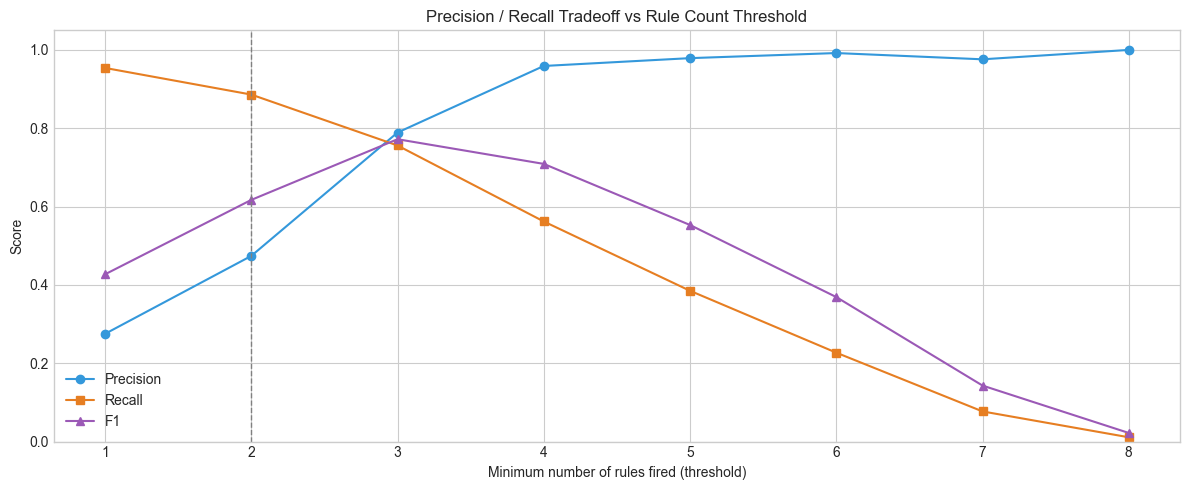

Figure: As the threshold for number of co-occurring signals increases, precision rises and recall falls. A threshold of 2 signals offers a reasonable precision/recall balance, consistent with the three-tier label design where 'suspected' requires at least 1 hard signal or 2 soft signals.


In [9]:
fig, ax = plt.subplots(figsize=FIGSIZE)

ax.plot(combo_df["Min rules fired"], combo_df["Precision"], marker="o", label="Precision", color="#3498db")
ax.plot(combo_df["Min rules fired"], combo_df["Recall"], marker="s", label="Recall", color="#e67e22")
ax.plot(combo_df["Min rules fired"], combo_df["F1"], marker="^", label="F1", color="#9b59b6")

ax.set_xlabel("Minimum number of rules fired (threshold)")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall Tradeoff vs Rule Count Threshold")
ax.set_xticks(combo_df["Min rules fired"])
ax.set_ylim(0, 1.05)
ax.legend()
ax.axvline(2, color="gray", linestyle="--", linewidth=1, label="Recommended threshold")

plt.tight_layout()
plt.show()
print("Figure: As the threshold for number of co-occurring signals increases, precision rises and recall falls. A threshold of 2 signals offers a reasonable precision/recall balance, consistent with the three-tier label design where 'suspected' requires at least 1 hard signal or 2 soft signals.")

## 6. Rule Correlation Analysis

Are rules measuring different things, or are they redundant? Highly correlated rules don't add information when combined.

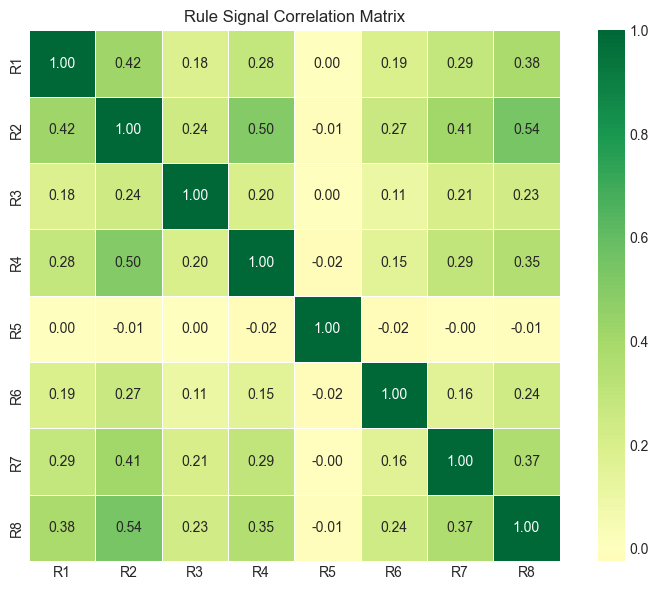

Figure: Correlation matrix of rule flags. Low inter-rule correlation indicates that most rules capture distinct signals, making their combination informative. High correlation (R2 and R4) suggests these rules share a common underlying signal — quota exhaustion — and one may be redundant.


In [10]:
short_names = [r.split(":")[0] for r in rule_flags.columns]
corr = rule_flags.rename(columns=dict(zip(rule_flags.columns, short_names))).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Rule Signal Correlation Matrix")
plt.tight_layout()
plt.show()
print("Figure: Correlation matrix of rule flags. Low inter-rule correlation indicates that most rules capture distinct signals, making their combination informative. High correlation (R2 and R4) suggests these rules share a common underlying signal — quota exhaustion — and one may be redundant.")

## 7. Key Findings

**What works:**
- Disposable email (R1) has the highest precision of any single rule — when it fires, it's almost always abuse. But it has low recall; sophisticated abusers use webmail.
- Fast quota exhaustion (R2) has strong recall — most abuse accounts exhaust quota quickly. Precision is moderate because some legitimate developers also exhaust quota rapidly.
- Combining 2+ signals reaches a reasonable operating point for `suspected` labeling.

**What doesn't work well:**
- IP cluster (R3) alone has poor precision — legitimate users at universities, corporations, and shared housing trigger it constantly.
- Datacenter/VPN ASN (R5) alone has low precision for the same reason: many developers and privacy-conscious users route through VPNs legitimately.

**The fundamental limit of rules:**
Rule-based systems are interpretable and fast, but they cannot capture the behavioral *patterns* that distinguish sophisticated abusers from legitimate edge cases. The ML notebook addresses this by learning decision boundaries from the full feature space rather than applying fixed thresholds.